In [27]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
from tqdm.auto import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor 
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

In [8]:
std_scaler = StandardScaler()

In [3]:
def get_stations_near_roi(
    st_mtdta_df: pd.DataFrame,
    lat_min=37.353455, lat_max=37.378862,
    long_min=-121.931501, long_max=-121.888125,
    fwy_a=101, fwy_b=880, buffer=1.5
):
    """
    gets stations upstream and downstream of an interchanges in a region of interest
    """
    region_df = st_mtdta_df[
        (st_mtdta_df['Latitude']>=lat_min) & (st_mtdta_df['Latitude']<=lat_max) &
        (st_mtdta_df['Longitude']>=long_min) & (st_mtdta_df['Longitude']<=long_max)
    ].copy()
    
    print(len(region_df), " Number of stations in this region.") # 58 stations in this region

    # finding stations in interchange, simple approach using name discription
    interchange_rows_a = region_df[(region_df["Fwy"] == fwy_a) & (region_df["Name"].str.contains(str(fwy_b)))]
    interchange_rows_b = region_df[(region_df["Fwy"] == fwy_b) & (region_df["Name"].str.contains(str(fwy_a)))]
    
    min_a, max_a = interchange_rows_a["Abs_PM"].min(), interchange_rows_a["Abs_PM"].max()
    min_b, max_b = interchange_rows_b["Abs_PM"].min(), interchange_rows_b["Abs_PM"].max()
    
    # Main corridors
    ml_a = region_df[(region_df["Fwy"] == fwy_a) & (region_df['Type'] == "ML")]
    ml_b = region_df[(region_df["Fwy"] == fwy_b) & (region_df['Type'] == "ML")] 
    
    u_a_nb = ml_a[(ml_a['Dir'] == 'N') & (ml_a['Abs_PM'] >= min_a - buffer) & (ml_a['Abs_PM'] < min_a)].sort_values('Abs_PM', ascending=True)
    d_a_nb = ml_a[(ml_a['Dir'] == 'N') & (ml_a['Abs_PM'] > max_a) & (ml_a['Abs_PM'] <= max_a + buffer)].sort_values('Abs_PM', ascending=True)
    
    u_a_sb = ml_a[(ml_a['Dir'] == 'S') & (ml_a['Abs_PM'] > max_a) & (ml_a['Abs_PM'] <= max_a + buffer)].sort_values('Abs_PM', ascending=False)
    d_a_sb = ml_a[(ml_a['Dir'] == 'S') & (ml_a['Abs_PM'] >= min_a - buffer) & (ml_a['Abs_PM'] < min_a)].sort_values('Abs_PM', ascending=False)
    
    
    u_b_nb = ml_b[(ml_b["Dir"] == 'N') & (ml_b['Abs_PM'] >= min_b - buffer) & (ml_b['Abs_PM'] < min_b)].sort_values('Abs_PM', ascending=True)
    d_b_nb = ml_b[(ml_b["Dir"] == 'N') & (ml_b['Abs_PM'] > max_b) & (ml_b['Abs_PM'] <= max_b + buffer)].sort_values('Abs_PM', ascending=True)
    
    u_b_sb = ml_b[(ml_b["Dir"] == 'S') & (ml_b['Abs_PM'] > max_b) & (ml_b['Abs_PM'] <= max_b + buffer)].sort_values('Abs_PM', ascending=False)
    d_b_sb = ml_b[(ml_b["Dir"] == 'S') & (ml_b['Abs_PM'] >= min_b - buffer) & (ml_b['Abs_PM'] < min_b)].sort_values('Abs_PM', ascending=False)

    # 4. Package into an organized dictionary
    results = {
        f"{fwy_a}_NB_upstream": u_a_nb,
        f"{fwy_a}_NB_downstream": d_a_nb,
        f"{fwy_a}_SB_upstream": u_a_sb,
        f"{fwy_a}_SB_downstream": d_a_sb,
        f"{fwy_b}_NB_upstream": u_b_nb,
        f"{fwy_b}_NB_downstream": d_b_nb,
        f"{fwy_b}_SB_upstream": u_b_sb,
        f"{fwy_b}_SB_downstream": d_b_sb
    }

    return results

def param_mat(parameter: str, selected_ids: list, filtered_df: pd.DataFrame):
    filtered_param_mat = filtered_df.pivot(
        index='timestamp',
        columns='station',
        values=f"{parameter}"
    )
    filtered_param_mat = filtered_param_mat[selected_ids]
    return filtered_param_mat

In [5]:
data_folder = Path("/mnt/c/Users/tanbi/OneDrive/Documents/sn_bose")
print("Data path exist? ", data_folder.exists())

station_metadata_path  = '/mnt/c/Users/tanbi/OneDrive/Documents/sn_bose/station_metadata/d04_text_meta_2025_10_16.txt'
print("station metadata path exits? ", os.path.exists(station_metadata_path))
st_mtdta_df = pd.read_csv(station_metadata_path, sep='\t')

corridors = get_stations_near_roi(st_mtdta_df)

# Station IDs
selected_ids = set()
for corridor_name, corridor_df in corridors.items():
    selected_ids.update(corridor_df['ID'].tolist())
selected_ids = list(selected_ids)

print(f"Total unique stations to extract data for: {len(selected_ids)}")
print(selected_ids)

# Parameters list
params = ["total_flow", "avg_occupancy", "avg_speed"]

columns_12 = [
    "timestamp", "station", "district", "freeway", "direction", "lane_type", 
    "station_length", "samples", "perc_obs", "total_flow", "avg_occupancy", "avg_speed"
]

rest_columns = [
    col
    for i in range(1, 9)
    for col in [
        f"lane_{i}_samples", 
        f"lane_{i}_flow", 
        f"lane_{i}_avg_occp", 
        f"lane_{i}_avg_speed", 
        f"lane_{i}_observed"        
    ]
]

all_X = []

for file in tqdm(
    sorted(data_folder.glob("d04_text_station_5min_*.txt")),
    desc="Processing daily files"
):
    print(f"Reading {file.name}")
    
    data_df = pd.read_csv(file, header=None)
    data_df.columns = columns_12 + rest_columns
    
    filtered_df = data_df[data_df['station'].isin(selected_ids)]
    
    X = []
    for param in params:
        p_mat =  param_mat(param, selected_ids, filtered_df)
        X.append(p_mat)

    all_X.append(X)

Data path exist?  True
station metadata path exits?  True
58  Number of stations in this region.
Total unique stations to extract data for: 12
[401440, 400965, 401541, 400971, 400109, 400911, 422357, 401560, 402364, 402365, 400030, 400863]


Processing daily files:   0%|                                                                                                                                          | 0/30 [00:00<?, ?it/s]

Reading d04_text_station_5min_2026_01_01.txt


Processing daily files:   3%|████▎                                                                                                                             | 1/30 [00:07<03:36,  7.46s/it]

Reading d04_text_station_5min_2026_01_02.txt


...

Processing daily files:  93%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍        | 28/30 [03:52<00:17,  8.69s/it]

Reading d04_text_station_5min_2026_01_29.txt


Processing daily files:  97%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋    | 29/30 [04:01<00:08,  8.94s/it]

Reading d04_text_station_5min_2026_01_30.txt


Processing daily files: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [04:10<00:00,  8.34s/it]


In [6]:
all_X = np.array(all_X)
all_X = all_X.transpose(0, 2, 3, 1)
print(all_X.shape)

(30, 288, 12, 3)


In [9]:
total_timestamps, num_stations, num_features = (
    all_X.shape[0] * all_X.shape[1],
    all_X.shape[2],
    all_X.shape[3]
)
continuous_data = all_X.reshape(total_timestamps, num_stations*num_features)
train_len = 21*288
val_len = 4*288

raw_train = continuous_data[:train_len]
raw_val = continuous_data[train_len : train_len+val_len]
raw_test = continuous_data[train_len+val_len:]

scaled_train = std_scaler.fit_transform(raw_train)
scaled_val = std_scaler.transform(raw_val)
scaled_test = std_scaler.transform(raw_test)

def create_3d_dataset(data, window=12):
    X, y = [], []
    for t in range(window, len(data)):
        X.append(data[t-window : t])
        y.append(data[t])
    return np.array(X), np.array(y)

X_train, y_train = create_3d_dataset(scaled_train, window=12)
X_val, y_val = create_3d_dataset(scaled_val, window=12)
X_test, y_test = create_3d_dataset(scaled_test, window=12)

In [10]:
print("X_train shape (samples, sequence_length, features):", X_train.shape)

X_train shape (samples, sequence_length, features): (6036, 12, 36)


In [23]:
lstm_model = Sequential([
    # input shape : (12, 36)
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False),
    Dropout(0),
    Dense(y_train.shape[1]) # predicts 36 values of step t
])

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=64
)

Epoch 1/15


/home/saytan/projects/traffic_congestion/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.3521 - mae: 0.3600 - val_loss: 0.1419 - val_mae: 0.2259
Epoch 2/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1186 - mae: 0.2032 - val_loss: 0.0982 - val_mae: 0.1837
Epoch 3/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0778 - mae: 0.1663 - val_loss: 0.0810 - val_mae: 0.1646
Epoch 4/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0620 - mae: 0.1493 - val_loss: 0.0696 - val_mae: 0.1527
Epoch 5/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0540 - mae: 0.1391 - val_loss: 0.0629 - val_mae: 0.1450
Epoch 6/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0491 - mae: 0.1326 - val_loss: 0.0590 - val_mae: 0.1409
Epoch 7/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0458 - mae: 0.1277 - val_loss: 0.0552 - val_mae: 0.1358
Epoch 8/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0433 - mae: 0.1239 - val_loss: 0.0526 - val_mae: 0.1329
Epoch 9/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0414 - mae: 0.

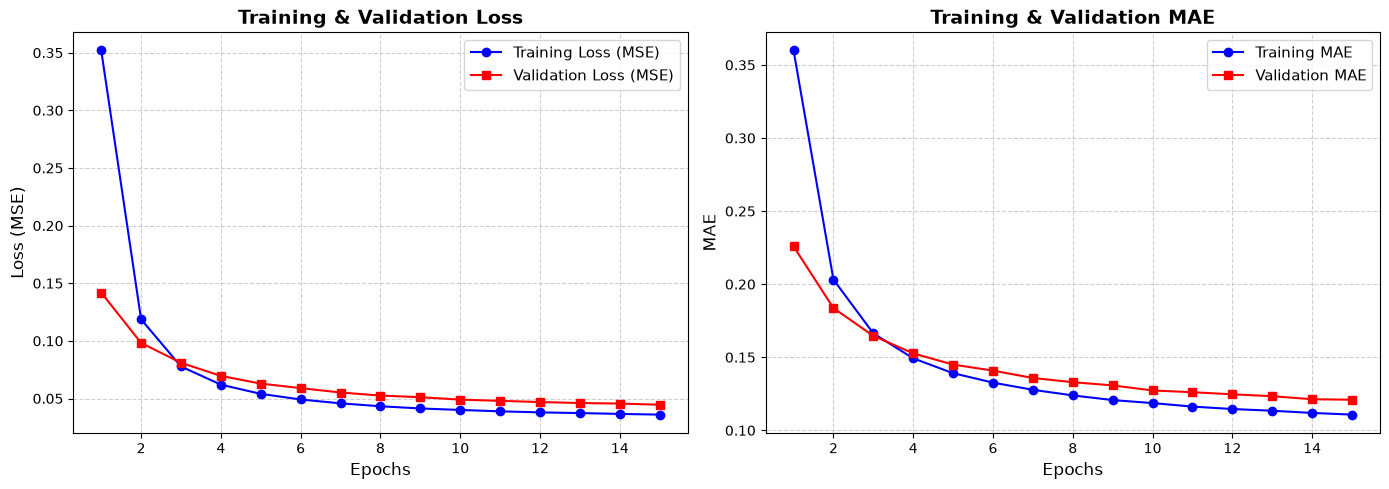

In [24]:
# loss curves LSTM model 1
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_mae = history.history['mae']
val_mae = history.history['val_mae']
epochs = range(1, len(train_loss)+1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, 'b-o', label='Training Loss (MSE)')
plt.plot(epochs, val_loss, 'r-s', label='Validation Loss (MSE)')
plt.title('Training & Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(epochs, train_mae, 'b-o', label='Training MAE')
plt.plot(epochs, val_mae, 'r-s', label='Validation MAE')
plt.title('Training & Validation MAE', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('MAE', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [26]:
# evaluating LSTM model 1 
y_pred_test_scaled = lstm_model.predict(X_test)
y_pred_test_orig = std_scaler.inverse_transform(y_pred_test_scaled)
y_test_orig = std_scaler.inverse_transform(y_test)
rmse_test = np.sqrt(mean_squared_error(y_test_orig, y_pred_test_orig))
mae_test = mean_absolute_error(y_test_orig, y_pred_test_orig)

mask_test = y_test_orig > 1.0
mape_test = np.mean(np.abs((y_test_orig[mask_test] - y_pred_test_orig[mask_test]) / (y_test_orig[mask_test] + 1e-5))) * 100

r2_test = r2_score(y_test_orig, y_pred_test_orig)

print("=" * 40)
print("       OVERALL LSTM MODEL PERFORMANCE        ")
print("=" * 40)
print(f"MAE  (Mean Absolute Error )     : {mae_test:.2f}")
print(f"RMSE (Root Mean Squared Error )  : {rmse_test:.2f}")
print(f"MAPE (Percentage Error )        : {mape_test:.2f}%")
print(f"R²   (Variance Explained )      : {r2_test:.4f}")
print("=" * 40)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
       OVERALL LSTM MODEL PERFORMANCE        
MAE  (Mean Absolute Error )     : 6.23
RMSE (Root Mean Squared Error )  : 14.59
MAPE (Percentage Error )        : 6.56%
R²   (Variance Explained )      : 0.9543


In [29]:
lstm_model2 = Sequential([
    # input shape : (12, 36)
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False),
    Dropout(0),
    Dense(y_train.shape[1]) # predicts 36 values of step t
])
lstm_model2.compile(optimizer='adam', loss='mse', metrics=['mae'])
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history1 = lstm_model2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.3550 - mae: 0.3629 - val_loss: 0.1428 - val_mae: 0.2257
Epoch 2/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.1203 - mae: 0.2010 - val_loss: 0.0977 - val_mae: 0.1789
Epoch 3/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0794 - mae: 0.1665 - val_loss: 0.0790 - val_mae: 0.1612
Epoch 4/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0633 - mae: 0.1492 - val_loss: 0.0695 - val_mae: 0.1514
Epoch 5/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0547 - mae: 0.1389 - val_loss: 0.0639 - val_mae: 0.1469
Epoch 6/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0498 - mae: 0.1322 - val_loss: 0.0584 - val_mae: 0.1383
Epoch 7/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0460 - mae: 0.1272 - val_loss: 0.0562 - val_mae: 0.1365
Epoch 8/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0437 - mae: 0.1235 - val_loss: 0.0528 - val_mae: 0.1318
Epoch 9/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.041

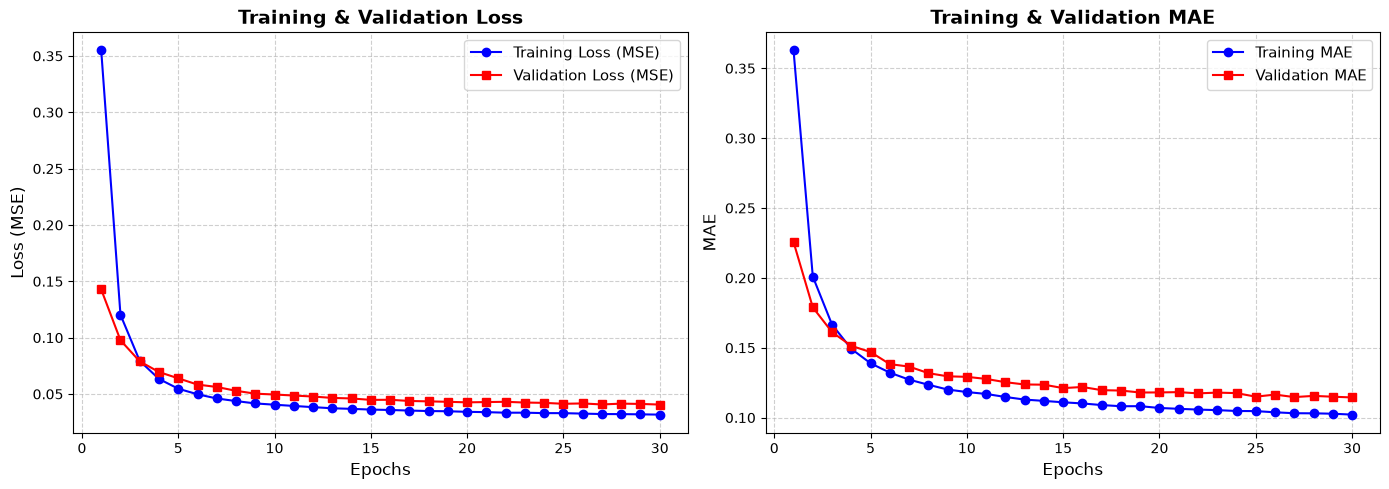

In [30]:
# loss curves LSTM model 2
train_loss = history1.history['loss']
val_loss = history1.history['val_loss']
train_mae = history1.history['mae']
val_mae = history1.history['val_mae']
epochs = range(1, len(train_loss)+1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, 'b-o', label='Training Loss (MSE)')
plt.plot(epochs, val_loss, 'r-s', label='Validation Loss (MSE)')
plt.title('Training & Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(epochs, train_mae, 'b-o', label='Training MAE')
plt.plot(epochs, val_mae, 'r-s', label='Validation MAE')
plt.title('Training & Validation MAE', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('MAE', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [31]:
# evaluating LSTM model 2
y_pred_test_scaled = lstm_model2.predict(X_test)
y_pred_test_orig = std_scaler.inverse_transform(y_pred_test_scaled)
y_test_orig = std_scaler.inverse_transform(y_test)
rmse_test = np.sqrt(mean_squared_error(y_test_orig, y_pred_test_orig))
mae_test = mean_absolute_error(y_test_orig, y_pred_test_orig)

mask_test = y_test_orig > 1.0
mape_test = np.mean(np.abs((y_test_orig[mask_test] - y_pred_test_orig[mask_test]) / (y_test_orig[mask_test] + 1e-5))) * 100

r2_test = r2_score(y_test_orig, y_pred_test_orig)

print("=" * 40)
print("       OVERALL LSTM MODEL 2 PERFORMANCE        ")
print("=" * 40)
print(f"MAE  (Mean Absolute Error )     : {mae_test:.2f}")
print(f"RMSE (Root Mean Squared Error )  : {rmse_test:.2f}")
print(f"MAPE (Percentage Error )        : {mape_test:.2f}%")
print(f"R²   (Variance Explained )      : {r2_test:.4f}")
print("=" * 40)

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
       OVERALL LSTM MODEL 2 PERFORMANCE        
MAE  (Mean Absolute Error )     : 5.95
RMSE (Root Mean Squared Error )  : 14.09
MAPE (Percentage Error )        : 6.25%
R²   (Variance Explained )      : 0.9590
